In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
import pickle

with open("SVM_full_dataset_results.pkl", "rb") as f:
    SVM_full_results = pickle.load(f)

with open("SVM_limited_dataset_results.pkl", "rb") as f:
    SVM_limited_results = pickle.load(f)

with open('QSVC_limited_dataset_results.pkl', 'rb') as f:
    QSVC_limited_results = pickle.load(f)

In [4]:
SVM_full_results.keys()

dict_keys(['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-Full', 'Scratch', 'Random'])

In [9]:
metrics_labels = {0:'Accuracy', 1:'Recall', 2:'Precision', 3:'F1 Score'}

In [13]:
len(SVM_full_results['Center'][0])

30

In [17]:
def convert_dict_into_dataframe(results_dict):
    rows = []

    for defect_class, metric_lists in results_dict.items():
        for metric_idx, scores in enumerate(metric_lists):
            metric_name = metrics_labels[metric_idx]
            
            for dim_idx, score in enumerate(scores, start=1):
                rows.append({
                    "Class": defect_class,
                    "Metric": metric_name,
                    "Dimension_Index": dim_idx,
                    "Score": score
                })

    df = pd.DataFrame(rows)

    return df

In [41]:
SVM_full_df = convert_dict_into_dataframe(SVM_full_results)
SVM_limited_df = convert_dict_into_dataframe(SVM_limited_results)
QSVC_limited_df = convert_dict_into_dataframe(QSVC_limited_results)

In [32]:
temp_df = pd.DataFrame(SVM_full_df.groupby(['Dimension_Index', 'Class'])["Score"].mean()).reset_index()

<Axes: xlabel='Dimension_Index', ylabel='Score'>

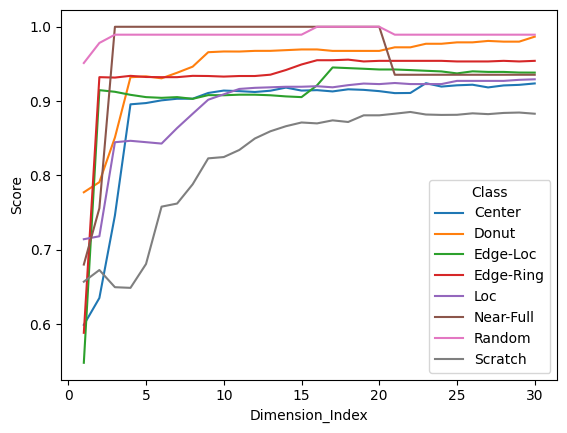

In [33]:
sns.lineplot(data=temp_df, x="Dimension_Index", y="Score", hue="Class")

In [38]:
def results_chart_maker(df,title):
    plot_df = (
        df
        .groupby(["Dimension_Index", "Class"])["Score"]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    for class_name, class_df in plot_df.groupby("Class"):
        class_df = class_df.sort_values("Dimension_Index")
        ax.plot(
            class_df["Dimension_Index"],
            class_df["Score"],
            marker="o",
            label=class_name
        )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("PCA dimensions (n components)")
    ax.set_ylabel("Avg. of accuracy, recall, precision, F1 score")
    ax.set_ylim(0, 1)
    ax.grid(True)
    ax.legend(title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

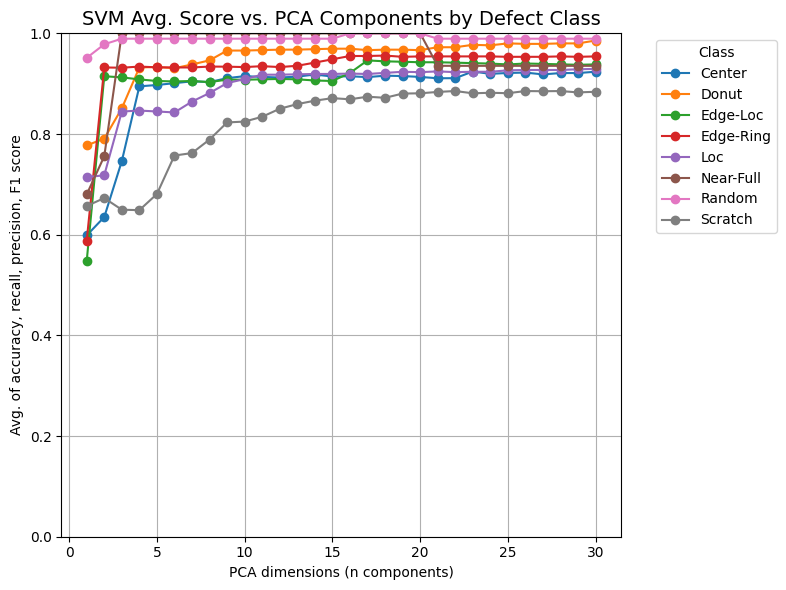

In [45]:
results_chart_maker(SVM_limited_df, "SVM Avg. Score vs. PCA Components by Defect Class")

In [66]:
def model_comparison_chart_maker(
    df_1,
    df_2,
    label_1="SVM",
    label_2="QSVC",
    title="Model Performance vs. PCA Components by Defect Class\neach line represents measured score for 1 of 8 defects",
    color_1="gray",
    color_2="orange"
):
    metrics_order = ["Accuracy", "Recall", "Precision", "F1 Score"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=14)

    for ax, metric_name in zip(axes.flatten(), metrics_order):
        metric_df_1 = df_1[df_1["Metric"] == metric_name]
        metric_df_2 = df_2[df_2["Metric"] == metric_name]

        plot_df_1 = (
            metric_df_1
            .groupby(["Dimension_Index", "Class"])["Score"]
            .mean()
            .reset_index()
        )

        plot_df_2 = (
            metric_df_2
            .groupby(["Dimension_Index", "Class"])["Score"]
            .mean()
            .reset_index()
        )

        for class_name, class_df in plot_df_1.groupby("Class"):
            class_df = class_df.sort_values("Dimension_Index")
            ax.plot(
                class_df["Dimension_Index"],
                class_df["Score"],
                marker="o",
                color=color_1,
                alpha=0.7,
                label=label_1 if class_name == list(plot_df_1["Class"].unique())[0] else None
            )

        for class_name, class_df in plot_df_2.groupby("Class"):
            class_df = class_df.sort_values("Dimension_Index")
            ax.plot(
                class_df["Dimension_Index"],
                class_df["Score"],
                marker="o",
                color=color_2,
                alpha=0.7,
                label=label_2 if class_name == list(plot_df_2["Class"].unique())[0] else None
            )

        ax.set_title(metric_name)
        ax.set_xlabel("PCA dimensions (n components)")
        ax.set_ylabel("Avg Score")
        ax.set_ylim(0, 1)
        ax.grid(True)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig("model_comparison_chart.png", dpi=300)
    plt.show()

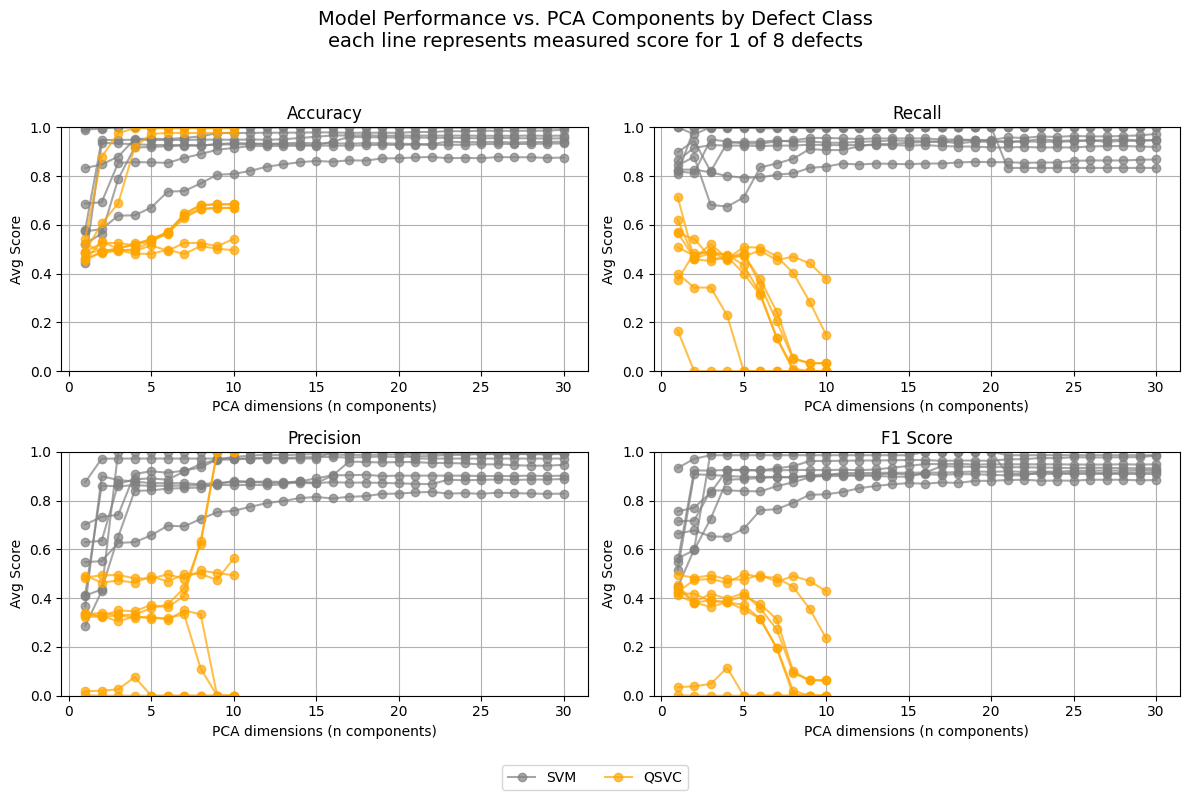

In [67]:
model_comparison_chart_maker(
    SVM_limited_df,
    QSVC_limited_df,
    label_1="SVM",
    label_2="QSVC")